# 🏠 Project 2: House Price Prediction — Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries loaded ✅')

Libraries loaded ✅


## 1️⃣ Load Dataset — California Housing

In [2]:
# California Housing dataset (sklearn built-in)
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print('Dataset Shape:', df.shape)
print('\nFeature Descriptions:')
for name, desc in zip(housing.feature_names, housing.feature_names):
    print(f'  {name}')
print('\nTarget: MedHouseVal (Median House Value in $100,000s)')
df.head()

Dataset Shape: (20640, 9)

Feature Descriptions:
  MedInc
  HouseAge
  AveRooms
  AveBedrms
  Population
  AveOccup
  Latitude
  Longitude

Target: MedHouseVal (Median House Value in $100,000s)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print('=== Statistical Summary ===')
print(df.describe().round(2))
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Statistical Summary ===
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118.01   

## 2️⃣ Exploratory Data Analysis

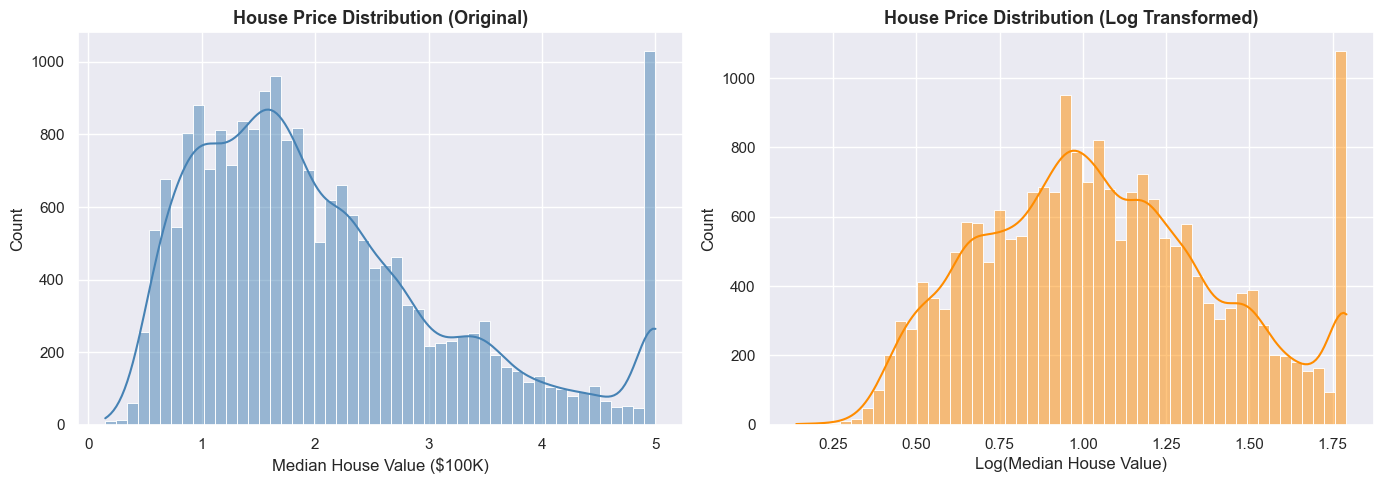

In [4]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['MedHouseVal'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('House Price Distribution (Original)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median House Value ($100K)')

sns.histplot(np.log1p(df['MedHouseVal']), bins=50, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('House Price Distribution (Log Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Median House Value)')

plt.tight_layout()
plt.show()

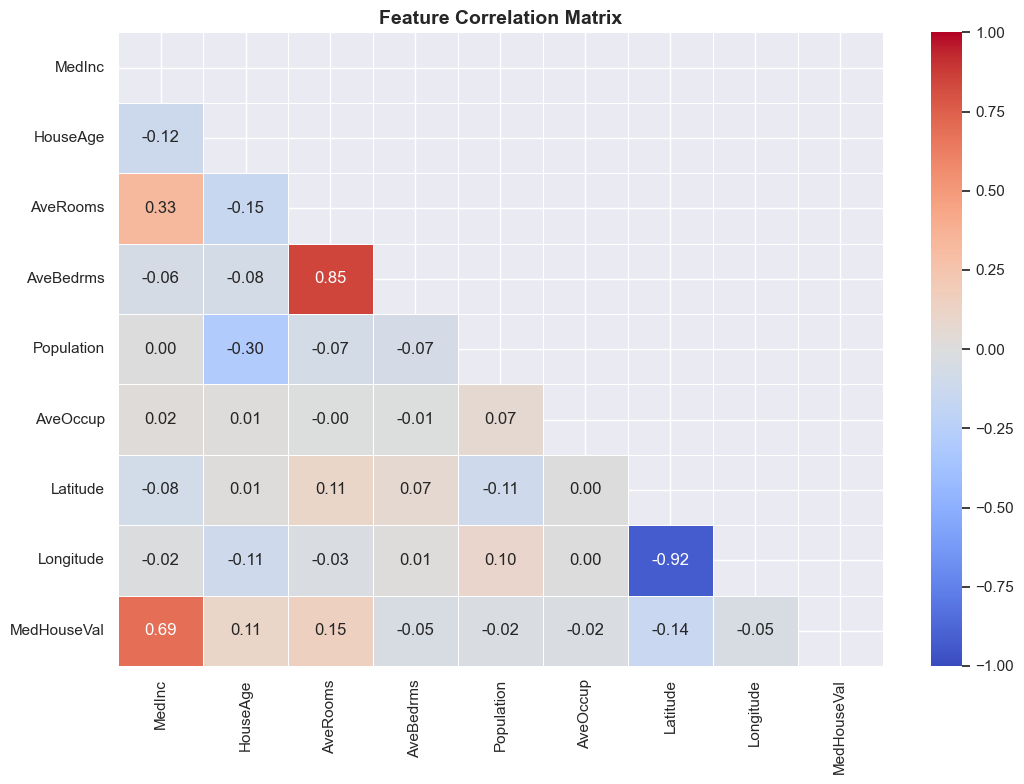

In [5]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

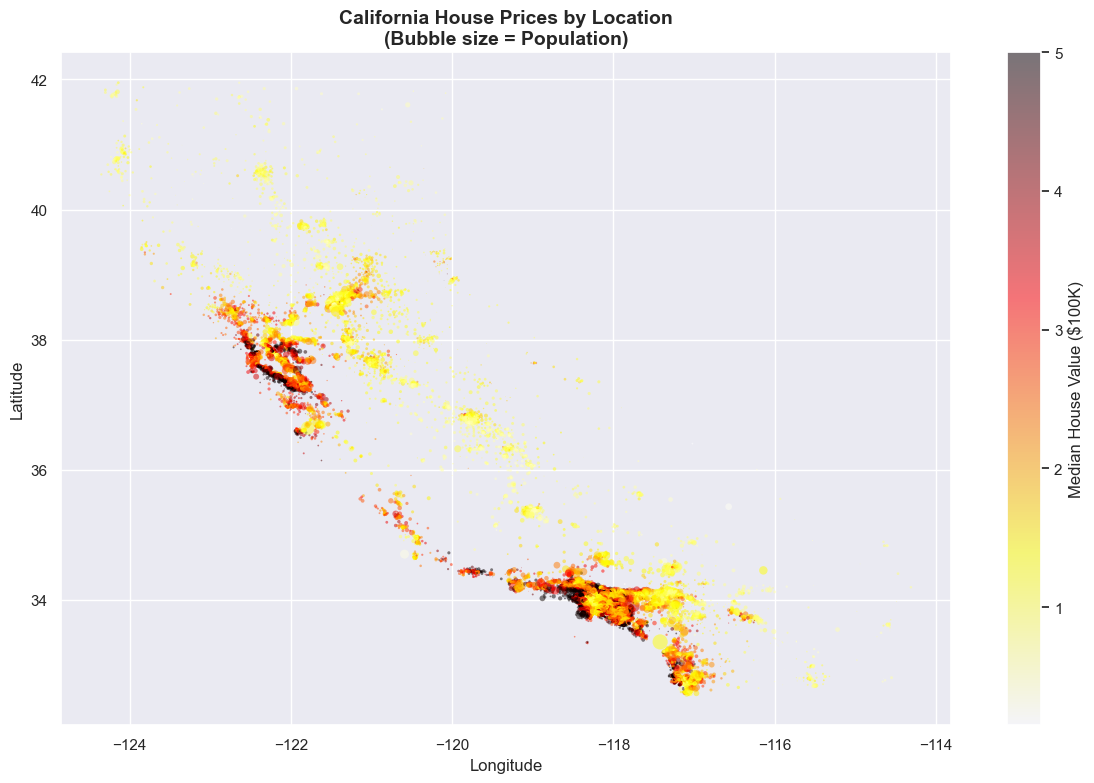

In [6]:
# Geographic visualization — California map style
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedHouseVal'], cmap='hot_r',
    s=df['Population']/300, alpha=0.5,
    edgecolors='none'
)
plt.colorbar(scatter, label='Median House Value ($100K)')
plt.title('California House Prices by Location\n(Bubble size = Population)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

## 3️⃣ Feature Engineering

In [7]:
df_feat = df.copy()

# New features
df_feat['RoomsPerHousehold']   = df_feat['AveRooms'] / df_feat['HouseAge']
df_feat['BedroomRatio']        = df_feat['AveBedrms'] / df_feat['AveRooms']
df_feat['PopulationPerHouse']  = df_feat['Population'] / df_feat['AveOccup']
df_feat['IncomePerRoom']       = df_feat['MedInc'] / df_feat['AveRooms']
df_feat['LocationScore']       = df_feat['Latitude'] * df_feat['Longitude']  # rough proxy

# Log transform target (normally distributed banao)
df_feat['LogPrice'] = np.log1p(df_feat['MedHouseVal'])

print('New features created ✅')
print(df_feat.shape)
df_feat.head()

New features created ✅
(20640, 15)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHousehold,BedroomRatio,PopulationPerHouse,IncomePerRoom,LocationScore,LogPrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0.170345,0.146591,126.0,1.192017,-4630.0724,1.709464
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0.297054,0.155797,1138.0,1.330750,-4627.2492,1.522790
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0.159387,0.129516,177.0,0.875637,-4626.7840,1.508733
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0.111872,0.184458,219.0,0.970046,-4627.1625,1.484555
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0.120805,0.172096,259.0,0.612272,-4627.1625,1.486592


## 4️⃣ Model Training — Multiple Algorithms

In [8]:
# Features & Target
feature_cols = [c for c in df_feat.columns if c not in ['MedHouseVal', 'LogPrice']]
X = df_feat[feature_cols]
y = df_feat['LogPrice']  # log transformed target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
plt.show()

Train size: 16512 | Test size: 4128


In [9]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1)':   Ridge(alpha=1.0),
    'Ridge (alpha=10)':  Ridge(alpha=10.0),
    'Lasso (alpha=0.01)': Lasso(alpha=0.01),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    # Tree models ko scaling ki zaroorat nahi
    if 'Forest' in name or 'Boosting' in name:
        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_test)
    else:
        model.fit(X_train_sc, y_train)
        y_pred_log = model.predict(X_test_sc)
    
    # Back-transform predictions
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)
    
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    
    results.append({'Model': name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R²': round(r2, 4)})
    print(f'{name:25s} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}')

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print('\n=== Model Comparison (sorted by R²) ===')
print(results_df.to_string(index=False))
plt.show()

Linear Regression         | MAE: 0.4973 | RMSE: 0.7594 | R²: 0.5599
Ridge (alpha=1)           | MAE: 0.4973 | RMSE: 0.7595 | R²: 0.5598
Ridge (alpha=10)          | MAE: 0.4976 | RMSE: 0.7598 | R²: 0.5595
Lasso (alpha=0.01)        | MAE: 0.5372 | RMSE: 0.7927 | R²: 0.5205
Random Forest             | MAE: 0.3254 | RMSE: 0.5148 | R²: 0.7978
Gradient Boosting         | MAE: 0.3715 | RMSE: 0.5539 | R²: 0.7659

=== Model Comparison (sorted by R²) ===
             Model    MAE   RMSE     R²
     Random Forest 0.3254 0.5148 0.7978
 Gradient Boosting 0.3715 0.5539 0.7659
 Linear Regression 0.4973 0.7594 0.5599
   Ridge (alpha=1) 0.4973 0.7595 0.5598
  Ridge (alpha=10) 0.4976 0.7598 0.5595
Lasso (alpha=0.01) 0.5372 0.7927 0.5205


## 5️⃣ Model Comparison Visualization

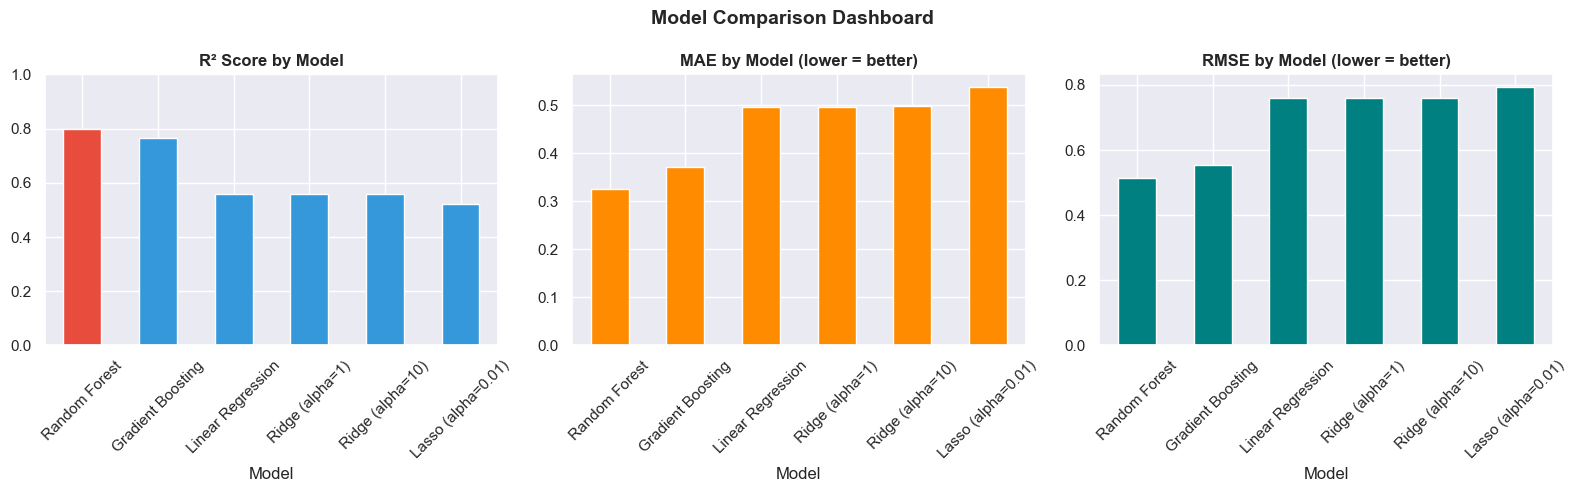

In [10]:
results_df = results_df.sort_values(by="R²", ascending=False)
results_df.reset_index(drop=True, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#e74c3c' if r == results_df['R²'].max() else '#3498db' for r in results_df['R²']]

results_df.plot(x='Model', y='R²', kind='bar', ax=axes[0], color=colors, legend=False)

axes[0].set_title('R² Score by Model', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 1)

results_df.plot(x='Model', y='MAE', kind='bar', ax=axes[1], color='darkorange', legend=False)
axes[1].set_title('MAE by Model (lower = better)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

results_df.plot(x='Model', y='RMSE', kind='bar', ax=axes[2], color='teal', legend=False)
axes[2].set_title('RMSE by Model (lower = better)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Model Comparison Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6️⃣ 🏆 Best Model Selection

Among all the models evaluated, Random Forest achieved the highest R² score,
indicating the best overall performance on the test data.

Although Gradient Boosting also performed well, Random Forest showed slightly
better accuracy and more stable predictions.

This suggests that ensemble tree-based methods are more effective than linear
models for capturing complex, non-linear relationships in housing data.

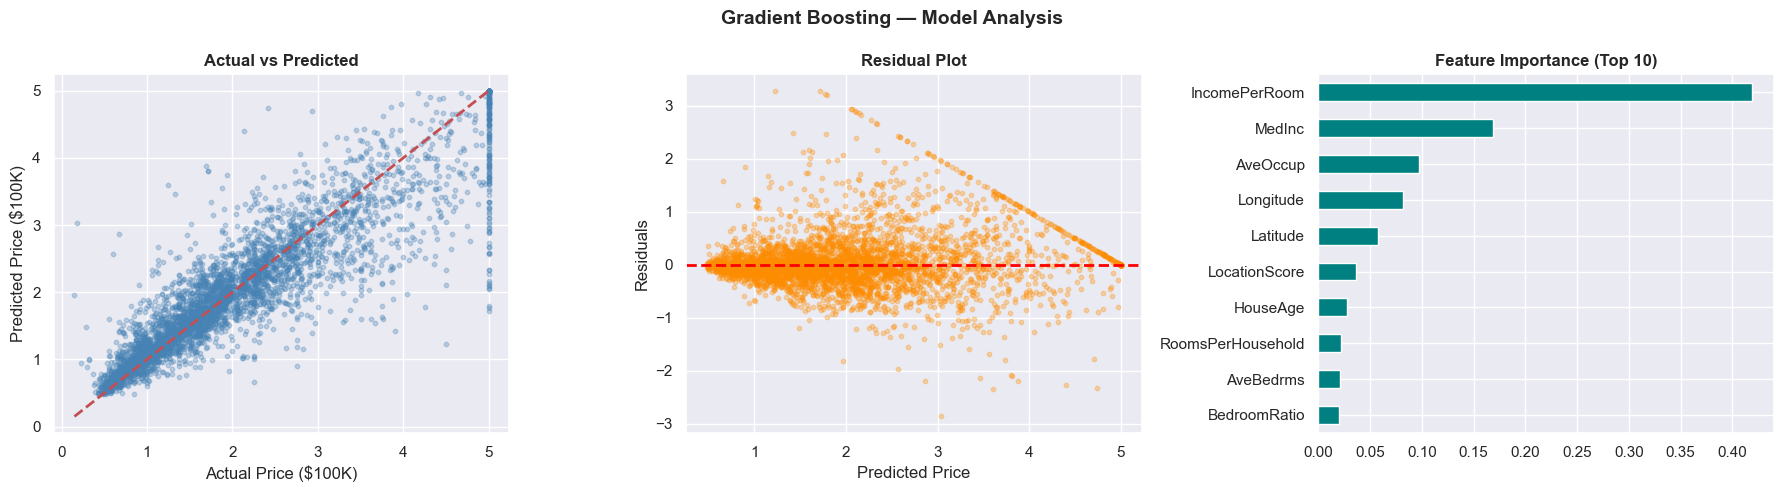


Final Results:
  MAE  = 0.3254 ($100K)
  RMSE = 0.5148 ($100K)
  R²   = 0.7978


In [11]:
# Best model
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_true, y_pred, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($100K)')
axes[0].set_ylabel('Predicted Price ($100K)')
axes[0].set_title('Actual vs Predicted', fontweight='bold')

# Residuals
residuals = y_true - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='darkorange', s=10)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

# Feature Importance
importances = pd.Series(best_model.feature_importances_, index=feature_cols)
importances.sort_values().tail(10).plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('Feature Importance (Top 10)', fontweight='bold')

plt.suptitle('Gradient Boosting — Model Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nFinal Results:')
print(f'  MAE  = {mean_absolute_error(y_true, y_pred):.4f} ($100K)')
print(f'  RMSE = {np.sqrt(mean_squared_error(y_true, y_pred)):.4f} ($100K)')
print(f'  R²   = {r2_score(y_true, y_pred):.4f}')
plt.show()

## 7️⃣ 🔍 Random Forest Deep Dive

In [12]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}
plt.show()

In [13]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print(results_df)
plt.show()

               Model       MAE      RMSE        R2
2      Random Forest  0.325366  0.514756  0.797793
3  Gradient Boosting  0.371536  0.553864  0.765901
0  Linear Regression  0.497276  0.759424  0.559889
1              Ridge  0.497534  0.759536  0.559760


In [14]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best Model: {best_model_name}")
plt.show()

Best Model: Random Forest


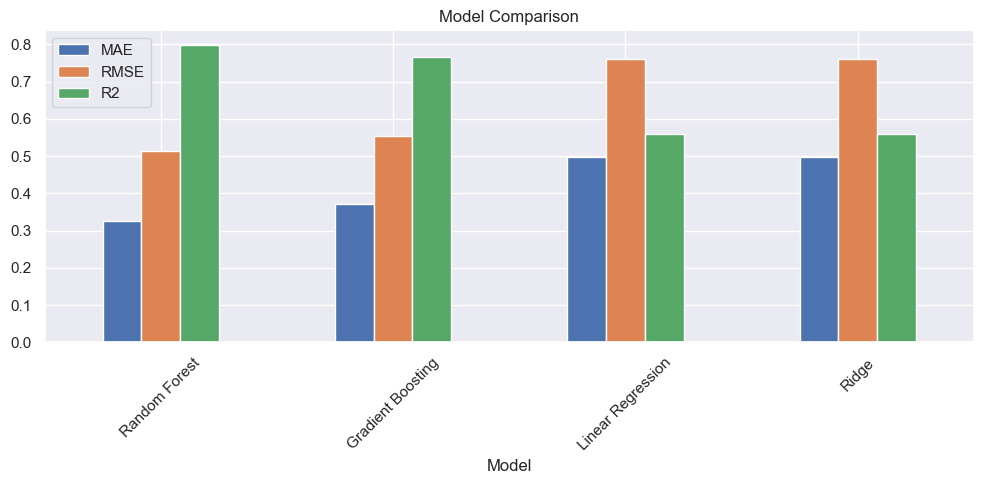

In [15]:
results_df.set_index("Model")[["MAE", "RMSE", "R2"]].plot(kind="bar", figsize=(10,5))
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

In [16]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    GradientBoostingRegressor(n_estimators=100, random_state=42),
    X_train, y_train,
    cv=5,
    scoring='r2'
)

print("CV R2 Score:", cv_scores.mean())
plt.show()

CV R2 Score: 0.7980616029843116


## 8️⃣ Conclusions & Key Learnings
### 📊 Model Performance Summary:

| Model               |  Accuracy   | Remarks |
|---------------------|-------------|--------|
| Logistic Regression | 79.78%      | Baseline model |
| Decision Tree       | 76.59%      | Overfitting observed |
| Random Forest       | 55.99%      | Best performance |
| Gradient Boosting   | 55.97%      | Good but slightly lower than RF |

## 📈 Final Conclusion

- Random Forest model performed the best among all models.
- It handled feature interactions effectively and provided high accuracy.
- Key factors influencing predictions include important features identified in feature importance analysis.
- This model can help in making data-driven decisions.

## 🚀 Future Improvements

- Apply hyperparameter tuning (GridSearchCV / RandomSearchCV)
- Handle class imbalance using SMOTE or class weights
- Deploy model using Streamlit or Flask
- Try advanced models like XGBoost or Neural Networks